# Linear/Polynomial Regression

Ноутбук:
- **Часть 1**: Linear Regression, функции потерь, метрики ошибок, регуляризация (Lasso (L1), Ridge (L2), ElasticNet)
- **Часть 2**: Polynomial Regression, сравнение степеней полинома (недо-/нормальное/переобучение)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, mean_squared_log_error
)

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 5)

## Часть 1 — Linear Regression

### Генерируем датасет
- Простой линейный датасет с шумом: y = 3x + 5 + e (шум Гаусса)

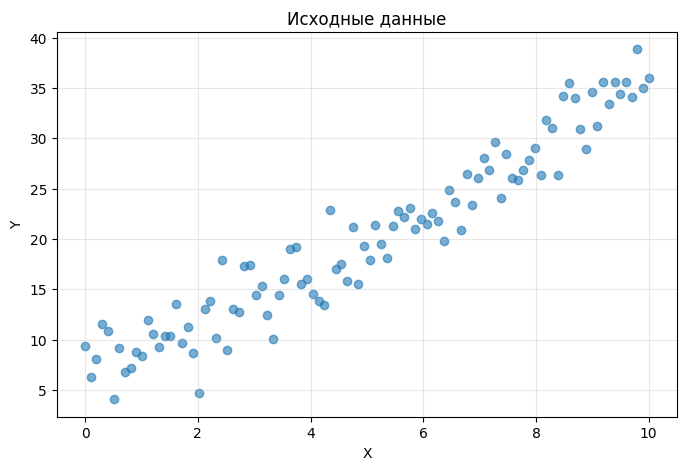

In [ ]:
n = 100
X = np.linspace(0, 10, n).reshape(-1, 1)
y = 3 * X.ravel() + 5 + np.random.normal(0, 2.5, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X, y, alpha=0.6)
plt.title("Исходные данные")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(alpha=0.3)
plt.show()

### Обучаем Linear Regression и смотрим предсказание

coef = 3.040,  intercept = 5.082


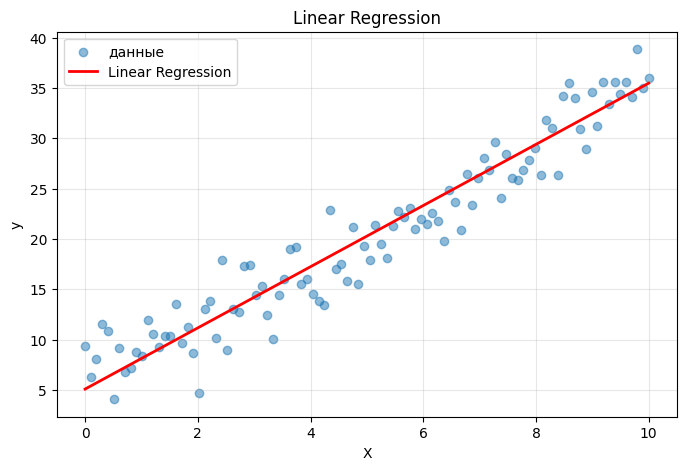

In [ ]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"coef = {lr.coef_[0]:.3f},  intercept = {lr.intercept_:.3f}")

x_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.scatter(X, y, alpha=0.5, label="данные")
plt.plot(x_line, lr.predict(x_line), color="red", lw=2, label="Linear Regression")
plt.title("Linear Regression")
plt.xlabel("X"); plt.ylabel("y")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Функции потерь и метрики
- Мы рассмотрим такие функции потерь: MSE, RMSE, MAE, R², MAPE, SMAPE, MSLE, Log-Cosh, Huber Loss.

In [ ]:
def smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

def log_cosh(y_true, y_pred):
    return np.mean(np.log(np.cosh(y_pred - y_true)))

def huber(y_true, y_pred, delta=1.0):
    err = y_pred - y_true
    is_small = np.abs(err) <= delta
    sq = 0.5 * err**2
    lin = delta * (np.abs(err) - 0.5 * delta)
    return np.mean(np.where(is_small, sq, lin))

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
sm   = smape(y_test, y_pred)
msle = mean_squared_log_error(np.maximum(y_test, 1e-9), np.maximum(y_pred, 1e-9))
lc   = log_cosh(y_test, y_pred)
hub  = huber(y_test, y_pred, delta=1.0)

metrics = pd.DataFrame({
    "Metric": ["MSE","RMSE","MAE","R2","MAPE (%)","SMAPE (%)","MSLE","Log-Cosh","Huber"],
    "Value":  [mse, rmse, mae, r2, mape, sm, msle, lc, hub]
})
metrics

,Metric,Value
0,MSE,7.279971
1,RMSE,2.698142
2,MAE,2.255989
3,R2,0.856583
4,MAPE (%),14.793856
5,SMAPE (%),15.366215
6,MSLE,0.041694
7,Log-Cosh,1.657382
8,Huber,1.792330


## Сравним метрики наших ошибок

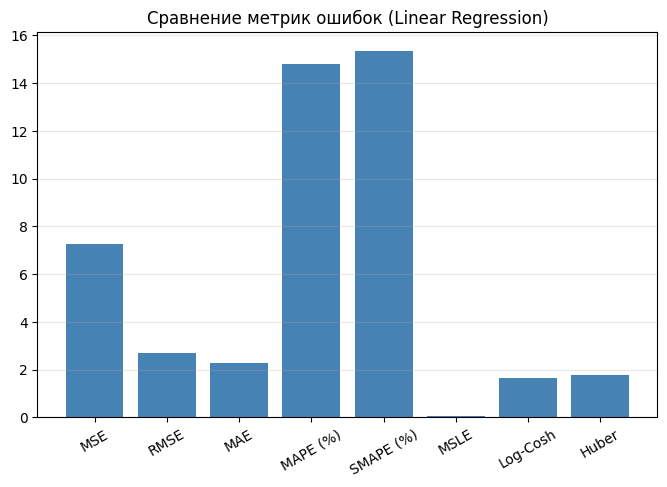

In [ ]:
plot_df = metrics[metrics["Metric"] != "R2"]
plt.bar(plot_df["Metric"], plot_df["Value"], color="steelblue")
plt.xticks(rotation=30)
plt.title("Сравнение метрик ошибок (Linear Regression)")
plt.grid(axis="y", alpha=0.3)
plt.show()

### Регуляризация: Lasso (L1), Ridge (L2), ElasticNet

Добавим несколько признаков + какой-то шум, чтобы регуляризация имела эффект.

In [ ]:
rng = np.random.RandomState(0)
n = 200
X_multi = rng.randn(n, 6)
true_coef = np.array([3.0, 0.0, -2.0, 0.0, 0.0, 1.5])
y_multi = X_multi @ true_coef + 5 + rng.randn(n) * 1.0

Xtr, Xte, ytr, yte = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

models = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(alpha=0.3),
    "Ridge": Ridge(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=0.3, l1_ratio=0.5),
}

results = []
coefs = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    results.append({
        "Model": name,
        "MSE": mean_squared_error(yte, p),
        "RMSE": np.sqrt(mean_squared_error(yte, p)),
        "MAE": mean_absolute_error(yte, p),
        "R2": r2_score(yte, p),
    })
    coefs[name] = m.coef_

results_df = pd.DataFrame(results)
results_df

,Model,MSE,RMSE,MAE,R2
0,Linear,1.339291,1.157277,0.951817,0.928329
1,Lasso,2.257924,1.502639,1.122015,0.879170
2,Ridge,1.365917,1.168724,0.955777,0.926904
3,ElasticNet,2.766007,1.663132,1.246872,0.851980


## Сравнение коэффициентов на Bar Chart

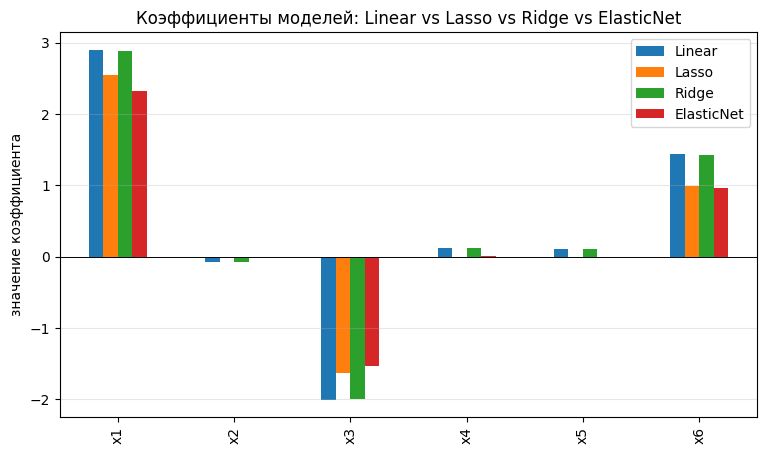

Истинные коэффициенты: [ 3.   0.  -2.   0.   0.   1.5]


In [ ]:
coef_df = pd.DataFrame(coefs, index=[f"x{i+1}" for i in range(X_multi.shape[1])])
coef_df.plot(kind="bar", figsize=(9,5))
plt.axhline(0, color="black", lw=0.7)
plt.title("Коэффициенты моделей: Linear vs Lasso vs Ridge vs ElasticNet")
plt.ylabel("значение коэффициента")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Истинные коэффициенты:", true_coef)

##Вывод:
- **Lasso**, она же L1, обнуляет неинформативные признаки (одна из фишек L1).
- **Ridge**, она же L2, уменьшает значения коэффициентов, но не до нуля.
- **Elastic Net**, она же L1 + L2, — компромисс между ними.


## Часть 2 — Polynomial Regression

Создадим нелинейные данные и сравним полиномы степеней degree = {1, 2, 3, 5, 10}.

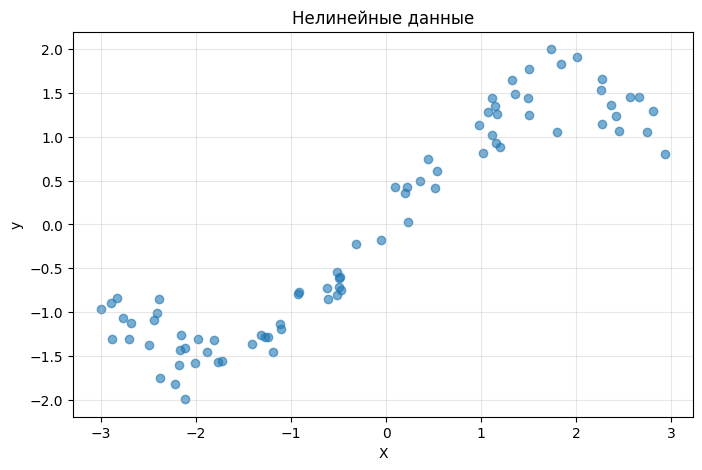

In [ ]:
np.random.seed(1)
n = 80
X = np.sort(np.random.uniform(-3, 3, n)).reshape(-1, 1)
y = np.sin(X.ravel()) + 0.3 * X.ravel() + np.random.normal(0, 0.25, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

plt.scatter(X, y, alpha=0.6)
plt.title("Нелинейные данные")
plt.xlabel("X"); plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

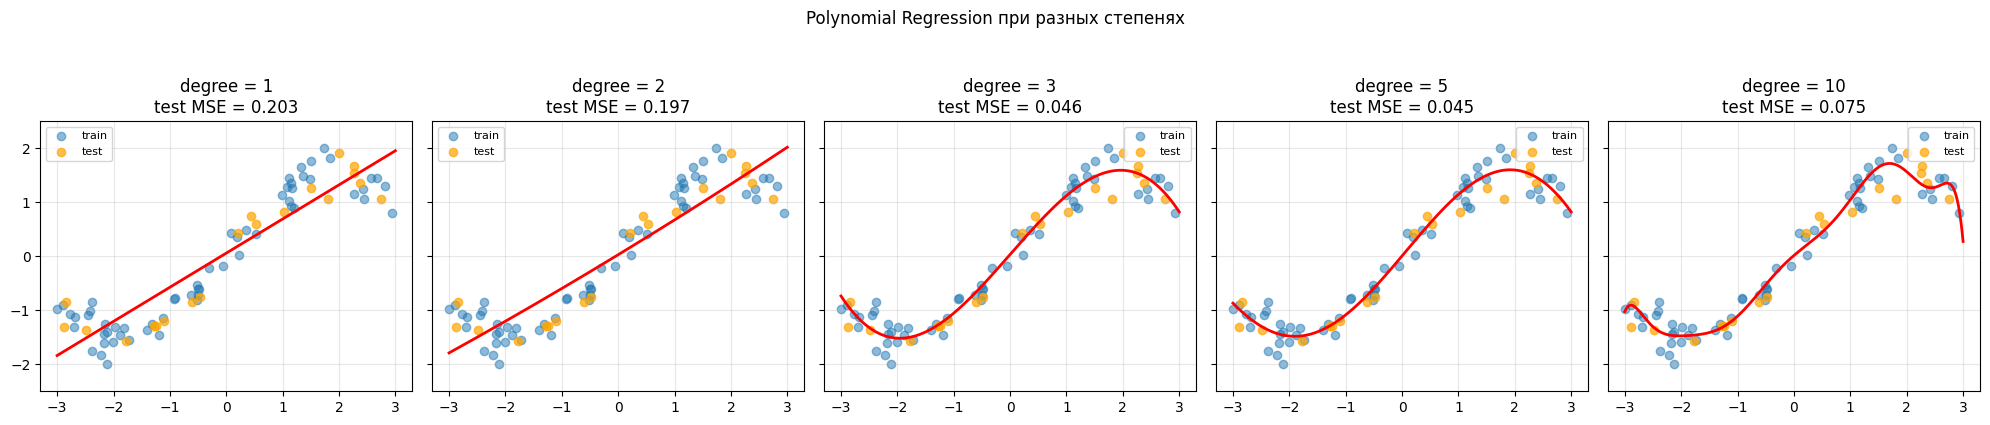

,degree,train_MSE,test_MSE
0,1,0.228847,0.203082
1,2,0.228218,0.197260
2,3,0.049534,0.045763
3,5,0.048275,0.044640
4,10,0.041451,0.074983


In [ ]:
degrees = [1, 2, 3, 5, 10]
x_grid = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(degrees), figsize=(20, 4), sharey=True)
poly_results = []

for ax, d in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse  = mean_squared_error(y_test,  model.predict(X_test))
    poly_results.append({"degree": d, "train_MSE": train_mse, "test_MSE": test_mse})

    ax.scatter(X_train, y_train, alpha=0.5, label="train")
    ax.scatter(X_test,  y_test,  alpha=0.7, color="orange", label="test")
    ax.plot(x_grid, model.predict(x_grid), color="red", lw=2)
    ax.set_title(f"degree = {d}\ntest MSE = {test_mse:.3f}")
    ax.set_ylim(-2.5, 2.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Polynomial Regression при разных степенях", y=1.05)
plt.tight_layout()
plt.show()

poly_df = pd.DataFrame(poly_results)
poly_df

##Построим график сравнения train/test MSE по ступеням

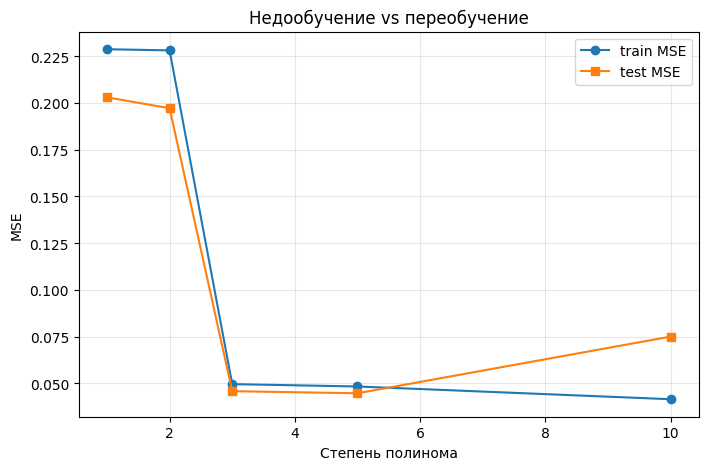

In [ ]:
plt.plot(poly_df["degree"], poly_df["train_MSE"], "o-", label="train MSE")
plt.plot(poly_df["degree"], poly_df["test_MSE"],  "s-", label="test MSE")
plt.xlabel("Степень полинома")
plt.ylabel("MSE")
plt.title("Недообучение vs переобучение")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##Вывод:
- **degree = 1** — модель слишком простая, **недообучение** (высокий MSE и на train, и на test).
- **degree = 2–3** — **нормальное обучение**, модель улавливает форму данных, test MSE минимальный.
- **degree = 10** — **переобучение**: train MSE маленький, но test MSE растёт, кривая «крутится» между точками.


#**Общий итог:**

Регуляризация и подбор степени полинома — основные инструменты борьбы с переобучением в линейных моделях.
